In [6]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Public\Documents\Axel\wcup26\data\clean_fotmob_match_stats.csv')
df.tail()

,teamId,teamName,matches,avg_xG,total_xG,avg_xG_open_play,avg_xG_set_play,avg_xG_non_penalty,mean_ball_possession,fouls,...,touches_opp_box,offsides,tackles_won,interceptions,blocks,clearances,keeper_saves,duel_won,yellow_cards,red_cards
43,287981,Curacao,2,0.455,0.91,0.365,0.09,0.455,30.0,441,...,22,3,33,24,11,57,19,102,5,0
44,6724,Paraguay,2,0.430,0.86,0.210,0.22,0.430,28.5,328,...,23,4,46,19,16,81,8,127,6,1
45,5902,Qatar,2,0.410,0.82,0.350,0.06,0.410,26.5,304,...,9,1,30,21,23,92,9,70,3,2
46,7795,Saudi Arabia,2,0.400,0.80,0.100,0.30,0.400,33.0,530,...,12,3,26,22,8,78,14,77,3,0
47,6719,Tunisia,2,0.165,0.33,0.025,0.14,0.165,44.5,576,...,18,7,39,20,7,36,2,89,1,0


In [7]:
df.columns

Index(['teamId', 'teamName', 'matches', 'avg_xG', 'total_xG',
       'avg_xG_open_play', 'avg_xG_set_play', 'avg_xG_non_penalty',
       'mean_ball_possession', 'fouls', 'accurate_passes',
       'accurate_long_passes', 'accurate_crosses', 'ground_duels_won',
       'aerial_won', 'dribbles_succeeded', 'goals', 'big_chances',
       'big_chances_missed', 'corners', 'total_shots', 'shots_off_target',
       'blocked_shots', 'hit_woodwork', 'shots_inside_box',
       'shots_outside_box', 'passes', 'own_half_passes',
       'opposition_half_passes', 'throws', 'touches_opp_box', 'offsides',
       'tackles_won', 'interceptions', 'blocks', 'clearances', 'keeper_saves',
       'duel_won', 'yellow_cards', 'red_cards'],
      dtype='str')

In [7]:
df[['teamName', 'goals', 'avg_xG']].sort_values(by='goals', ascending=False).head()

,teamName,goals,avg_xG
1,Germany,9,3.025
2,Canada,7,2.925
4,Norway,7,2.360
11,Netherlands,7,1.695
5,France,6,2.280


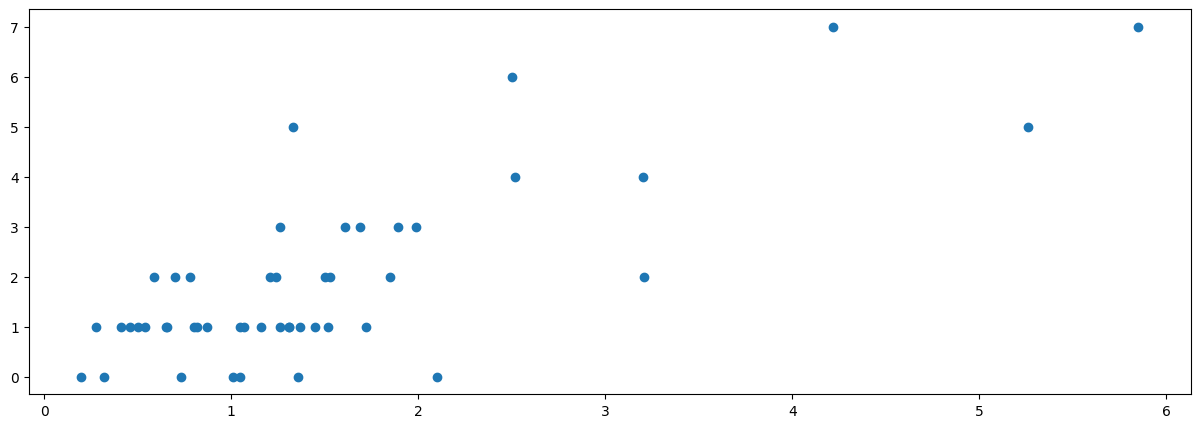

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.scatter(x=df.total_xG, y=df.goals)

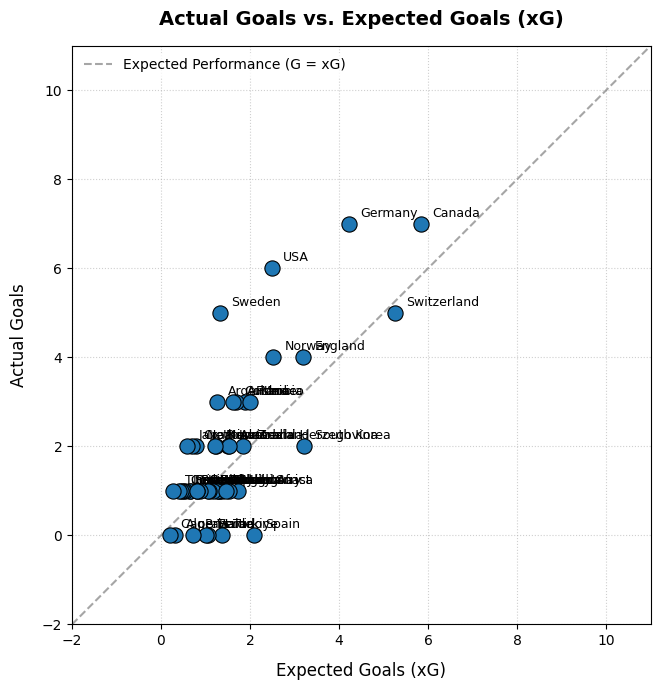

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data (matching the previous pandas DataFrame values)
players = ['Erling Haaland', 'Harry Kane', 'Mohamed Salah', 'Son Heung-min', 'Robert Lewandowski']
goals = [27, 36, 18, 17, 19]
xg = [24.3, 31.2, 20.1, 12.4, 21.5]

# 2. Initialize the plot
plt.figure(figsize=(8, 7), dpi=100)

# 3. Dynamic axis limit calculation to keep the chart perfectly square
max_val = max(max(df.goals), max(df.total_xG)) + 4
min_val = min(min(df.goals), min(df.total_xG)) - 2

# 4. Plot the 1:1 baseline (Where Goals == xG)
plt.plot([min_val, max_val], [min_val, max_val], 
         color='gray', 
         linestyle='--', 
         alpha=0.7, 
         linewidth=1.5,
         label='Expected Performance (G = xG)')

# 5. Plot the player data points
plt.scatter(df.total_xG, df.goals, 
            color='#1f77b4', 
            s=120, 
            edgecolors='black', 
            linewidths=0.8, 
            zorder=5)

# 6. Annotate each data point with the player's name
for i, name in enumerate(df.teamName):
    plt.annotate(
        name, 
        (df.total_xG[i], df.goals[i]), 
        xytext=(8, 5),             # Offsets the text slightly up and right
        textcoords='offset points', 
        fontsize=9,
        fontweight='medium'
    )

# 7. Labels, Title, and Formatting
plt.xlabel('Expected Goals (xG)', fontsize=12, labelpad=10)
plt.ylabel('Actual Goals', fontsize=12, labelpad=10)
plt.title('Actual Goals vs. Expected Goals (xG)', fontsize=14, fontweight='bold', pad=15)

# Ensure the plot is a perfect square visually to maintain line geometry
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')

# Add subtle layout helpers
plt.grid(True, linestyle=':', alpha=0.6, zorder=1)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# 8. Render the visualization
plt.tight_layout()
plt.show()


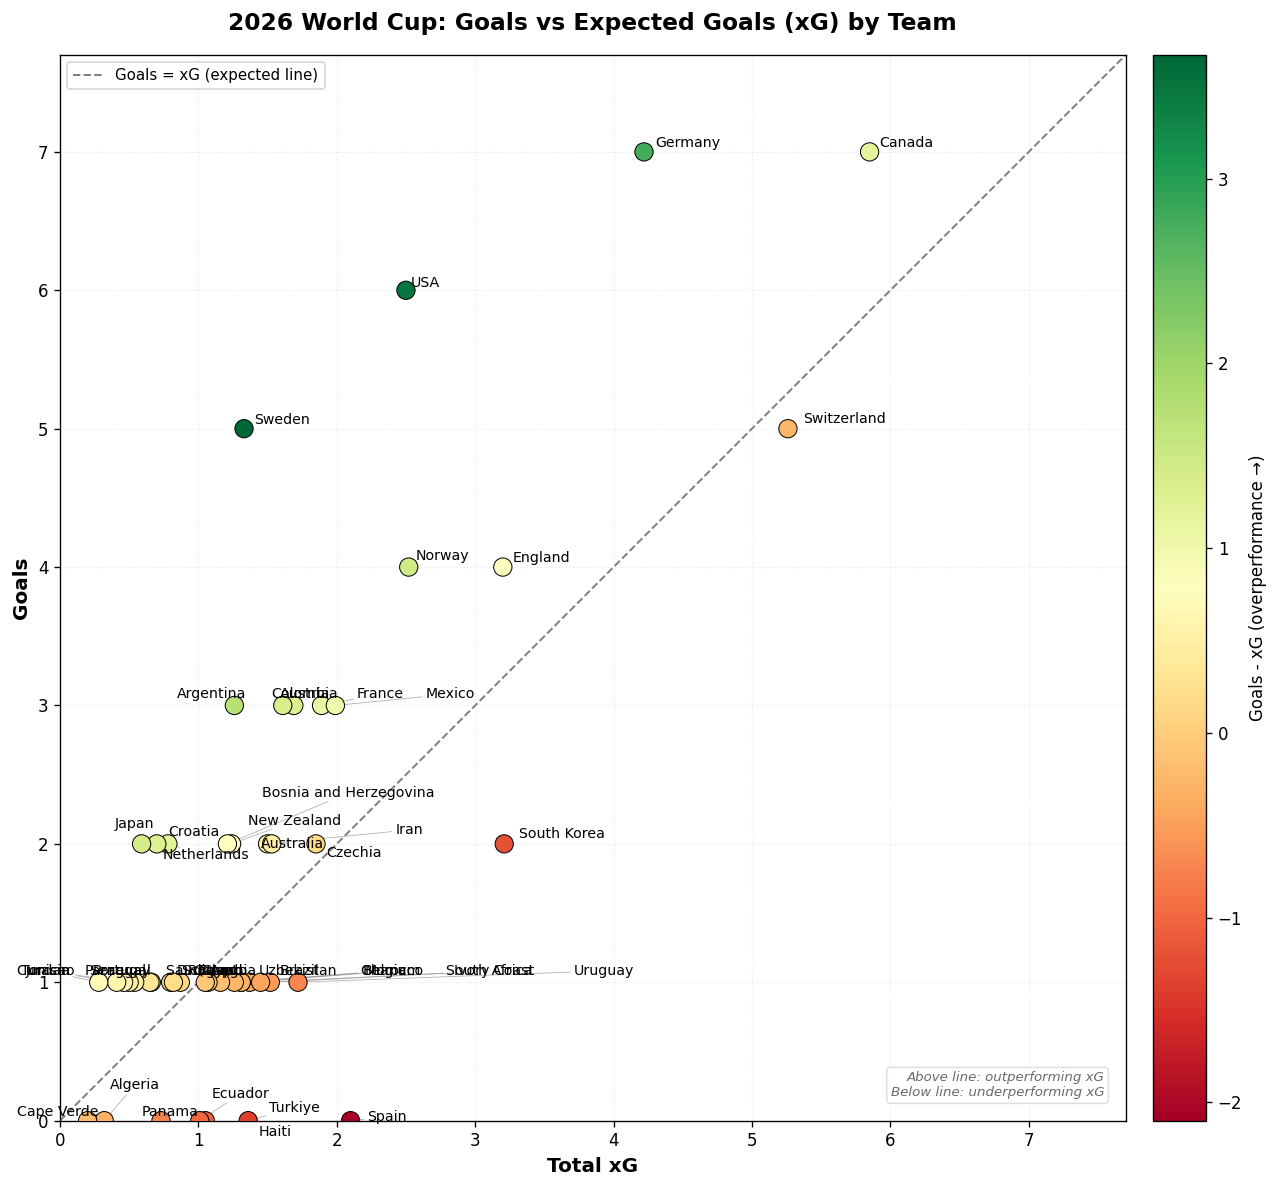

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(12, 10), dpi=120)

# Compute over/underperformance for coloring
df['xG_diff'] = df['goals'] - df['total_xG']

# Diagonal reference line (y = x) — defines "performed as expected"
max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1
min_val = 0
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle='--', color='gray', linewidth=1.2, zorder=1,
        label='Goals = xG (expected line)')

# Scatter, colored by over/underperformance
scatter = ax.scatter(
    df['total_xG'], df['goals'],
    c=df['xG_diff'], cmap='RdYlGn', s=120,
    edgecolors='black', linewidth=0.6, zorder=3
)

# Colorbar to explain the color coding
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Goals - xG (overperformance →)', fontsize=10)

# Team name labels, auto-adjusted to avoid overlap
texts = []
for _, row in df.iterrows():
    texts.append(
        ax.text(row['total_xG'], row['goals'], row['teamName'],
                fontsize=8.5, zorder=4)
    )
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_xlabel('Total xG', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals', fontsize=12, fontweight='bold')
ax.set_title('2026 World Cup: Goals vs Expected Goals (xG) by Team',
             fontsize=14, fontweight='bold', pad=15)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25, linestyle=':')
ax.legend(loc='upper left', fontsize=9, frameon=True)

# Subtle annotation explaining the diagonal
ax.text(0.98, 0.02, 'Above line: outperforming xG\nBelow line: underperforming xG',
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
        style='italic', color='dimgray',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='lightgray'))

plt.tight_layout()
plt.savefig('goals_vs_xg_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()

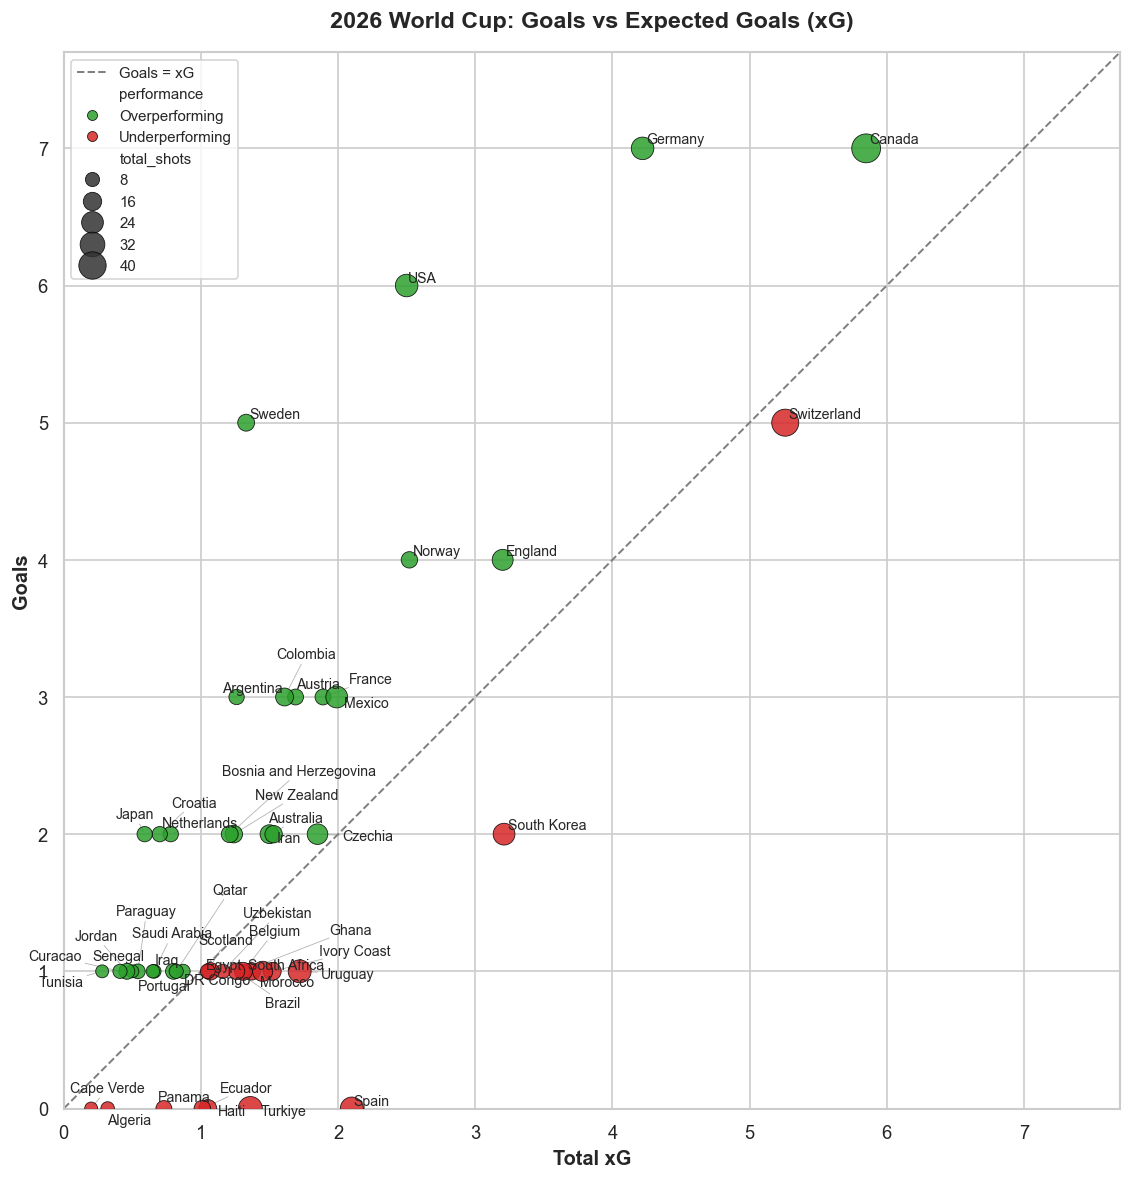

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

sns.set_theme(style='whitegrid', font_scale=1.0)

df['xG_diff'] = df['goals'] - df['total_xG']
df['performance'] = np.where(df['xG_diff'] >= 0, 'Overperforming', 'Underperforming')

fig, ax = plt.subplots(figsize=(12, 10), dpi=120)

max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1

# Diagonal reference line
ax.plot([0, max_val], [0, max_val],
        linestyle='--', color='gray', linewidth=1.2, zorder=1,
        label='Goals = xG')

# Seaborn scatterplot, sized by total_shots if you want an extra dimension
sns.scatterplot(
    data=df, x='total_xG', y='goals',
    hue='performance', palette={'Overperforming': '#2ca02c', 'Underperforming': '#d62728'},
    size='total_shots', sizes=(60, 300), alpha=0.85,
    edgecolor='black', linewidth=0.5, ax=ax, zorder=3
)

# Labels with adjustText to dodge overlaps
texts = [
    ax.text(row['total_xG'], row['goals'], row['teamName'], fontsize=8.5, zorder=4)
    for _, row in df.iterrows()
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Total xG', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals', fontsize=12, fontweight='bold')
ax.set_title('2026 World Cup: Goals vs Expected Goals (xG)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='', loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('goals_vs_xg_seaborn.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
import plotly.express as px

df['xG_diff'] = df['goals'] - df['total_xG']

fig = px.scatter(
    df, x='total_xG', y='goals', text='teamName',
    color='xG_diff', color_continuous_scale='RdYlGn',
    hover_data=['matches', 'total_shots', 'big_chances'],
    title='2026 World Cup: Goals vs xG'
)

max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1
fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val,
              line=dict(dash='dash', color='gray'))

fig.update_traces(textposition='top center', textfont_size=8, marker=dict(size=10))
fig.update_layout(xaxis_range=[0, max_val], yaxis_range=[0, max_val], width=900, height=900)
fig.show()